# Lesson 4. Driving the bicycle while it balances

Teleoperation means a person sends extra commands with a keyboard, an
on-screen stick, or a gamepad. The balance controller stays on. The stick
does not replace it.

## Learning objectives

By the end of this lesson you will be able to:

1. Map stick motion to speed and heading commands.
2. Explain why a turn is a disturbance to a loop whose job is to hold roll near 0°.
3. Compare a straight cruise with a held turn on two roll graphs.

## Glossary

| Term | Meaning |
| --- | --- |
| Teleoperation | A person drives the bicycle while the controller keeps running. |
| Disturbance | An extra command, such as a turn, that would increase lean if the controller did not react. |
| Disturbance rejection | Roll stays small while that extra command is applied. |
| Deadzone | A small band around stick center that is ignored, so noise does not change the speed. |
| Cruise | The usual forward speed, about 2.2 m/s, used when the stick is centered. |
| Heading | The direction the bicycle is pointing. |


## Step 1. Start the lesson

Run the next cell. Continue when you see `project_root:`.


In [1]:
import os
import sys

def choose_mujoco_gl(platform, display, existing):
    if existing:
        return existing
    if str(platform).startswith("linux") and not display:
        return "egl"
    return None

chosen = choose_mujoco_gl(sys.platform, os.environ.get("DISPLAY"), os.environ.get("MUJOCO_GL"))
if chosen and "MUJOCO_GL" not in os.environ:
    os.environ["MUJOCO_GL"] = chosen

def find_project_root(start=None):
    current = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(current, "run_sim.py")) and os.path.isfile(
            os.path.join(current, "sim", "__init__.py")
        ):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise RuntimeError(
        "Could not find bike_mujoco_sim. Start Jupyter from the folder that "
        "contains run_sim.py, or from its tutorials folder."
    )

project_root = find_project_root()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import replace

from sim.config import load_config
from sim.loop import make_sim, run_headless, summarize
from sim.pid_controller import RollSteerPID, apply_speed_refs

np.set_printoptions(precision=4, suppress=True)
print("project_root:", project_root)
print("platform:", sys.platform, "MUJOCO_GL:", os.environ.get("MUJOCO_GL", "(unset)"))


from sim.joystick import speed_goal_from_stick


project_root: /home/lmbike2/bike-workshop/bike_mujoco_sim
platform: linux MUJOCO_GL: egl


## Step 2. Read the stick map, then print three speeds

The stick springs back to the center when you release it. Center means no
extra command.

- **Stick Y (up / down)** sets speed. Center selects cruise, about 2.2 m/s.
  Full forward asks for a higher speed. Full back asks for a lower speed,
  including reverse. Motion inside the deadzone is ignored.
- **Stick X (left / right)** sets a turn. While you hold left, the software
  adds a turn rate on top of the balance PID. When you release, it stores
  the current heading and tries to keep that heading.
- **Key 0** commands speed 0. A stopped bicycle falls. Move the stick off
  center to leave the stop.
- **Space or Reset** puts the bicycle upright after a fall.

The roll PID stays on for the whole run.

Run the next cell. It loads a tuned gain set. If `configs/tutorial.yaml` is
still the weak set, the cell loads `configs/new_bike.yaml` instead.

Expected printout: a center-stick speed goal of `None` (cruise), a positive
full-forward speed, and a negative full-back speed.


In [2]:
# Prefer a tuned panel. Fall back to new_bike.yaml if tutorial.yaml is still weak.
tutorial_yaml = os.path.join(project_root, "configs", "tutorial.yaml")
new_bike_yaml = os.path.join(project_root, "configs", "new_bike.yaml")
cfg = load_config(tutorial_yaml)
if cfg.pid_kd_roll < 8.0 or cfg.pid_kp_roll < 6.0:
    cfg = load_config(new_bike_yaml)
    print("loaded tuned gains from", os.path.relpath(new_bike_yaml, project_root))
else:
    print("loaded", os.path.relpath(tutorial_yaml, project_root))
print(
    "outer gains kp={:.3f} ki={:.3f} kd={:.3f} kp_steer={:.3f}".format(
        cfg.pid_kp_roll, cfg.pid_ki_roll, cfg.pid_kd_roll, cfg.pid_kp_steer
    )
)
print("center stick speed goal", speed_goal_from_stick(0.0, cfg))
print("full forward", speed_goal_from_stick(1.0, cfg))
print("full back", speed_goal_from_stick(-1.0, cfg))


loaded tuned gains from configs/new_bike.yaml
outer gains kp=7.536 ki=1.261 kd=11.261 kp_steer=1.116
center stick speed goal None
full forward 3.5
full back -1.0


## Step 3. Drive the bicycle (optional)

This step is optional. Step 4 records the same idea as graphs.

The next cell opens two windows: the MuJoCo view of the bicycle, and a
small Bike joystick window. Drag the orange knob. It returns to center when
you release it.

Procedure:

1. Run the cell and let the bicycle cruise with the stick centered.
2. Hold the stick left, then release it. Watch the roll readout.
3. Close the MuJoCo window. The cell finishes only after that window closes.

If the cell reports that MuJoCo was already imported, choose
**Kernel → Restart Kernel** and run this cell again.


In [ ]:
import os
import sys

def find_project_root(start=None):
    current = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(current, "run_sim.py")) and os.path.isfile(
            os.path.join(current, "sim", "__init__.py")
        ):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise RuntimeError(
        "Could not find bike_mujoco_sim. Start Jupyter from the folder that "
        "contains run_sim.py, or from its tutorials folder."
    )

project_root = find_project_root()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

if "mujoco" in sys.modules and os.environ.get("MUJOCO_GL") not in (None, "", "glfw"):
    raise RuntimeError(
        "MuJoCo was already imported with MUJOCO_GL=%r. Restart the kernel, "
        "then run this cell again." % os.environ.get("MUJOCO_GL")
    )
os.environ["MUJOCO_GL"] = "glfw"

from dataclasses import replace
from sim.config import load_config
from sim.loop import make_sim
from sim.viewer import run_viewer

print("project_root:", project_root)
print("MUJOCO_GL:", os.environ.get("MUJOCO_GL"))


tutorial_yaml = os.path.join(project_root, "configs", "tutorial.yaml")
new_bike_yaml = os.path.join(project_root, "configs", "new_bike.yaml")
cfg = load_config(tutorial_yaml)
if cfg.pid_kd_roll < 8.0 or cfg.pid_kp_roll < 6.0:
    cfg = load_config(new_bike_yaml)
sim = make_sim(model_spec="new_bike", mode="remote", cfg=cfg)
print("Remote stick: center = cruise + hold heading. Close MuJoCo when done.")
run_viewer(sim)
print("Window closed.")


## Step 4. Compare a centered stick with a held turn

Two window cells, then one graph cell. Both use the tuned gains and remote mode.

1. First window: leave the on-screen stick centered for the whole run.
2. Second window: hold the stick to the left for the whole run.
3. Close each MuJoCo window before you start the next cell.
4. The graph cell repeats those two cases with `stick_x = 0` and `stick_x = 1`.

Read the two roll plots and decide how the lean compares.

If a window cell reports that MuJoCo was already imported, choose
**Kernel → Restart Kernel**, then run that window cell again.


In [ ]:
import os
import sys

def find_project_root(start=None):
    current = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(current, "run_sim.py")) and os.path.isfile(
            os.path.join(current, "sim", "__init__.py")
        ):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise RuntimeError(
        "Could not find bike_mujoco_sim. Start Jupyter from the folder that "
        "contains run_sim.py, or from its tutorials folder."
    )

project_root = find_project_root()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

if "mujoco" in sys.modules and os.environ.get("MUJOCO_GL") not in (None, "", "glfw"):
    raise RuntimeError(
        "MuJoCo was already imported with MUJOCO_GL=%r. Restart the kernel, "
        "then run this cell again." % os.environ.get("MUJOCO_GL")
    )
os.environ["MUJOCO_GL"] = "glfw"

from dataclasses import replace
from sim.config import load_config
from sim.loop import make_sim
from sim.viewer import run_viewer

print("project_root:", project_root)
print("MUJOCO_GL:", os.environ.get("MUJOCO_GL"))


tutorial_yaml = os.path.join(project_root, "configs", "tutorial.yaml")
new_bike_yaml = os.path.join(project_root, "configs", "new_bike.yaml")
cfg = load_config(tutorial_yaml)
if cfg.pid_kd_roll < 8.0 or cfg.pid_kp_roll < 6.0:
    cfg = load_config(new_bike_yaml)
cfg = replace(cfg, duration=4.0)
sim = make_sim(model_spec="new_bike", mode="remote", cfg=cfg)
print("Leave the stick centered. Close the MuJoCo window to finish this cell.")
run_viewer(sim)
print("Window closed.")


In [ ]:
import os
import sys

def find_project_root(start=None):
    current = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(current, "run_sim.py")) and os.path.isfile(
            os.path.join(current, "sim", "__init__.py")
        ):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise RuntimeError(
        "Could not find bike_mujoco_sim. Start Jupyter from the folder that "
        "contains run_sim.py, or from its tutorials folder."
    )

project_root = find_project_root()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

if "mujoco" in sys.modules and os.environ.get("MUJOCO_GL") not in (None, "", "glfw"):
    raise RuntimeError(
        "MuJoCo was already imported with MUJOCO_GL=%r. Restart the kernel, "
        "then run this cell again." % os.environ.get("MUJOCO_GL")
    )
os.environ["MUJOCO_GL"] = "glfw"

from dataclasses import replace
from sim.config import load_config
from sim.loop import make_sim
from sim.viewer import run_viewer

print("project_root:", project_root)
print("MUJOCO_GL:", os.environ.get("MUJOCO_GL"))


tutorial_yaml = os.path.join(project_root, "configs", "tutorial.yaml")
new_bike_yaml = os.path.join(project_root, "configs", "new_bike.yaml")
cfg = load_config(tutorial_yaml)
if cfg.pid_kd_roll < 8.0 or cfg.pid_kp_roll < 6.0:
    cfg = load_config(new_bike_yaml)
cfg = replace(cfg, duration=4.0)
sim = make_sim(model_spec="new_bike", mode="remote", cfg=cfg)
print("Hold the stick to the left. Close the MuJoCo window to finish this cell.")
run_viewer(sim)
print("Window closed.")


model:      /home/lmbike2/bike-workshop/bike_mujoco_sim/models/new_bike/new_bike.xml
mode:       remote center
simulated:  3.98s
max |roll|: 8.24 deg
final speed:2.182 m/s
mean |roll|: 5.68 deg
model:      /home/lmbike2/bike-workshop/bike_mujoco_sim/models/new_bike/new_bike.xml
mode:       remote stick_x=1
simulated:  3.98s
max |roll|: 8.76 deg
final speed:2.182 m/s
mean |roll|: 6.80 deg


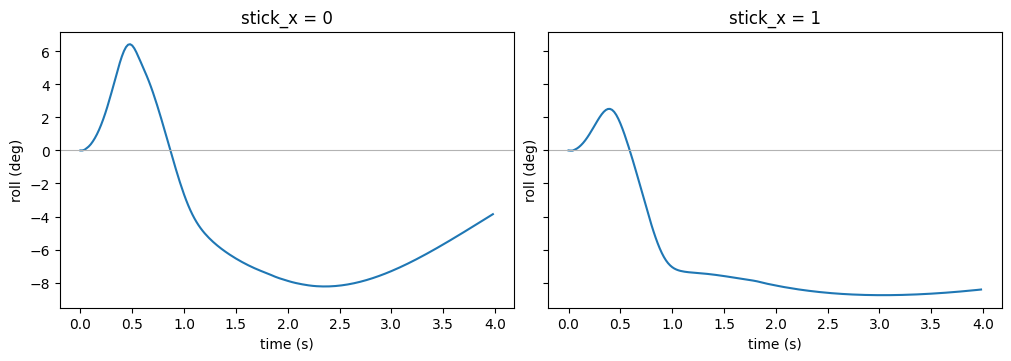

max |roll| while turning = 8.8 deg


In [6]:
def run_remote(stick_x, seconds=4.0):
    sim = make_sim(model_spec="new_bike", mode="remote", cfg=replace(cfg, duration=seconds))
    sim.goals.stick_x = float(stick_x)
    history = run_headless(sim, duration=seconds)
    return sim, history

straight_sim, straight = run_remote(0.0)
turn_sim, turning = run_remote(1.0)
summarize(straight, model_path=straight_sim.model_path, mode="remote center")
summarize(turning, model_path=turn_sim.model_path, mode="remote stick_x=1")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True, constrained_layout=True)
for ax, hist, title in (
    (axes[0], straight, "stick_x = 0"),
    (axes[1], turning, "stick_x = 1"),
):
    ax.plot(hist["time"], np.degrees(hist["roll"]))
    ax.axhline(0.0, color="0.7", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("time (s)")
    ax.set_ylabel("roll (deg)")
plt.show()

turn_roll = float(np.max(np.abs(np.degrees(turning["roll"]))))
print(f"max |roll| while turning = {turn_roll:.1f} deg")
if turn_roll > 30.0:
    raise RuntimeError("turn leaned too far; check that tuned gains are loaded")


## Step 5. Cruise with the speed schedule

The window cell, then the graph cell, use the speed schedule: a speed ramp
and no stick turn. Roll and speed share one figure. Compare that roll trace
with the two traces from Step 4.

If the window cell reports that MuJoCo was already imported, choose
**Kernel → Restart Kernel**, then run the window cell again.


In [ ]:
import os
import sys

def find_project_root(start=None):
    current = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(current, "run_sim.py")) and os.path.isfile(
            os.path.join(current, "sim", "__init__.py")
        ):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise RuntimeError(
        "Could not find bike_mujoco_sim. Start Jupyter from the folder that "
        "contains run_sim.py, or from its tutorials folder."
    )

project_root = find_project_root()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

if "mujoco" in sys.modules and os.environ.get("MUJOCO_GL") not in (None, "", "glfw"):
    raise RuntimeError(
        "MuJoCo was already imported with MUJOCO_GL=%r. Restart the kernel, "
        "then run this cell again." % os.environ.get("MUJOCO_GL")
    )
os.environ["MUJOCO_GL"] = "glfw"

from dataclasses import replace
from sim.config import load_config
from sim.loop import make_sim
from sim.viewer import run_viewer

print("project_root:", project_root)
print("MUJOCO_GL:", os.environ.get("MUJOCO_GL"))


tutorial_yaml = os.path.join(project_root, "configs", "tutorial.yaml")
new_bike_yaml = os.path.join(project_root, "configs", "new_bike.yaml")
cfg = load_config(tutorial_yaml)
if cfg.pid_kd_roll < 8.0 or cfg.pid_kp_roll < 6.0:
    cfg = load_config(new_bike_yaml)
cfg = replace(cfg, duration=6.0)
sim = make_sim(model_spec="new_bike", mode="speed-schedule", cfg=cfg)
print("speed schedule, duration", cfg.duration)
print("Close the MuJoCo window to finish this cell.")
run_viewer(sim)
print("Window closed.")


model:      /home/lmbike2/bike-workshop/bike_mujoco_sim/models/new_bike/new_bike.xml
mode:       speed-schedule
simulated:  6.00s
max |roll|: 6.56 deg
final speed:2.183 m/s
mean |roll|: 0.64 deg


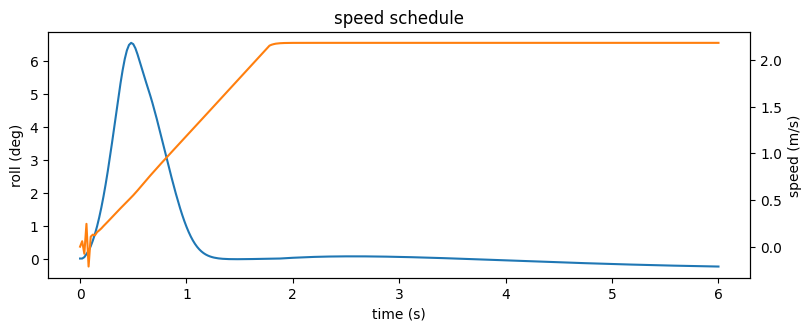

In [8]:
cruise = make_sim(model_spec="new_bike", mode="speed-schedule", cfg=replace(cfg, duration=6.0))
cruise_hist = run_headless(cruise, duration=6.0)
summarize(cruise_hist, model_path=cruise.model_path, mode="speed-schedule")
fig, ax = plt.subplots(figsize=(8, 3.2), constrained_layout=True)
ax.plot(cruise_hist["time"], np.degrees(cruise_hist["roll"]), label="roll")
ax.set_ylabel("roll (deg)")
ax.set_xlabel("time (s)")
ax2 = ax.twinx()
ax2.plot(cruise_hist["time"], cruise_hist["speed"], color="C1", label="speed")
ax2.set_ylabel("speed (m/s)")
ax.set_title("speed schedule")
plt.show()


## Discussion

### Why would a turn knock the bicycle over?

The balance loop is trying to hold roll near 0°. A turn also asks the handlebars to move. That extra request is a disturbance: it would increase the lean if the controller did not react. With the tuned gains, roll stays small while the turn is held.

### Did the stick turn the PID off?

The PID stays on for the whole ride. The stick adds a speed command or a heading command on top of it.

### Why did the centered stick lean less than the held turn?

A centered stick is cruise with no extra turn. The held turn is the disturbance, so that trace moves more. It still stays far from a fall.


## Questions

Answer these before you run the next cell.

1. In Step 4, which ride leaned more: the centered stick, or the stick held left?
2. Predict `stick_x = -1` (held to the right): does the maximum |roll| stay under 30°?

`stick_x = +1` is left. `stick_x = -1` is right. `0` is centered. Edit `stick_try`, run the cell, then try `0.5` and `-1`. Compare the maximum |roll| with your prediction and with the Step 4 rides.


In [9]:
# Edit stick_try and run again. Trials: -1, then 0.5, then 0
stick_try = -1.0

tutorial_yaml = os.path.join(project_root, "configs", "tutorial.yaml")
new_bike_yaml = os.path.join(project_root, "configs", "new_bike.yaml")
cfg = load_config(tutorial_yaml)
if cfg.pid_kd_roll < 8.0 or cfg.pid_kp_roll < 6.0:
    cfg = load_config(new_bike_yaml)
sim = make_sim(model_spec="new_bike", mode="remote", cfg=replace(cfg, duration=4.0))
sim.goals.stick_x = float(stick_try)
history = run_headless(sim, duration=4.0)
max_roll = float(np.max(np.abs(np.degrees(history["roll"]))))
print(f"stick_x = {float(stick_try):+.1f}")
print(f"max |roll| = {max_roll:.1f} deg")
if max_roll > 45.0:
    print("Result: fell.")
elif max_roll > 30.0:
    print("Result: stayed under 45 deg, and leaned past 30 deg.")
else:
    print("Result: held. Maximum |roll| stayed under 30 deg.")


stick_x = -1.0
max |roll| = 11.5 deg
Result: held. Maximum |roll| stayed under 30 deg.
